# W4: Scikit Classify Lin Reg

## Importing Libraries and Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("top2019.csv")
df.head()

,id,name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,6v3KW9xbzN5yKLt9YKDYA,Señorita,Shawn Mendes,0.759,0.548,9.0,-6.049,0.0,0.0290,0.0392,0.00,0.0828,0.749,116.967,190800.0,4.0
1,2Fxmhks0bxGSBdJ92vM42,bad guy,Billie Eilish,0.701,0.425,7.0,-10.965,1.0,0.3750,0.3280,0.13,0.1000,0.562,135.128,194088.0,4.0
2,0RiRZpuVRbi7oqRdSMwhQ,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,0.755,0.522,2.0,-4.368,1.0,0.0575,0.5330,0.00,0.0685,0.925,89.960,157560.0,4.0
3,6ocbgoVGwYJhOv1GgI9Ns,7 rings,Ariana Grande,0.778,0.317,1.0,-10.732,0.0,0.3340,0.5920,0.00,0.0881,0.327,140.048,178627.0,4.0
4,2YpeDb67231RjR0MgVLzs,Old Town Road - Remix,Lil Nas X,0.878,0.619,6.0,-5.560,1.0,0.1020,0.0533,0.00,0.1130,0.639,136.041,157067.0,4.0


## Machine Learning

- Machine learning trains computers to find patterns in data
- The goal of machine learning is to build a mathematical model from data that accurately predicts outcomes for brand new, unseen data
- Using this dataset, we can predict subject outcomes like danceabilty from object audio metrics like temp

## Data Summary Analysis

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50 non-null     object 
 1   name              50 non-null     object 
 2   artists           50 non-null     object 
 3   danceability      50 non-null     float64
 4   energy            50 non-null     float64
 5   key               50 non-null     float64
 6   loudness          50 non-null     float64
 7   mode              50 non-null     float64
 8   speechiness       50 non-null     float64
 9   acousticness      50 non-null     float64
 10  instrumentalness  50 non-null     float64
 11  liveness          50 non-null     float64
 12  valence           50 non-null     float64
 13  tempo             50 non-null     float64
 14  duration_ms       50 non-null     float64
 15  time_signature    50 non-null     float64
dtypes: float64(13), object(3)
memory usage: 6.4+ K

In [89]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0
mean,0.719400,0.60462,5.280000,-6.229000,0.580000,0.127582,0.299381,0.006039,0.132792,0.490460,120.425700,201691.620000,4.0
std,0.130358,0.16975,3.295266,2.725249,0.498569,0.103008,0.255321,0.029065,0.074088,0.219144,28.740856,44213.177325,0.0
min,0.351000,0.11100,0.000000,-14.505000,0.000000,0.029000,0.005130,0.000000,0.057400,0.120000,71.105000,113000.000000,4.0
25%,0.657500,0.52000,2.000000,-7.056000,0.000000,0.053675,0.095900,0.000000,0.088425,0.330500,97.316000,175840.000000,4.0
50%,0.743000,0.62400,5.000000,-5.759000,1.000000,0.081350,0.244000,0.000000,0.106000,0.495000,116.125500,193657.500000,4.0
75%,0.814500,0.73225,8.000000,-4.295250,1.000000,0.199000,0.449250,0.000003,0.141250,0.637000,137.478750,215372.250000,4.0
max,0.907000,0.90400,11.000000,-2.652000,1.000000,0.375000,0.978000,0.162000,0.437000,0.952000,179.974000,354320.000000,4.0


In [90]:
df.isnull().sum()

id                  0
name                0
artists             0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64

## Normalizing Data

In [91]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numeric_df=df.drop(columns=['id','name','artists'])
normalized_df=pd.DataFrame(scaler.fit_transform(numeric_df), columns=numeric_df.columns)
normalized_df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.733813,0.551072,0.818182,0.713406,0.0,0.000000,0.035020,0.000000,0.066913,0.756010,0.421259,0.322394,0.0
1,0.629496,0.395965,0.636364,0.298659,1.0,1.000000,0.331874,0.802469,0.112223,0.531250,0.588074,0.336019,0.0
2,0.726619,0.518285,0.181818,0.855227,1.0,0.082370,0.542590,0.000000,0.029241,0.967548,0.173190,0.184651,0.0
3,0.767986,0.259773,0.090909,0.318316,0.0,0.881503,0.603236,0.000000,0.080875,0.248798,0.633266,0.271950,0.0
4,0.947842,0.640605,0.545455,0.754661,1.0,0.210983,0.049513,0.000000,0.146470,0.623798,0.596460,0.182608,0.0


## Linear Regression Model

In [103]:
X_songs=normalized_df[['liveness','energy','tempo']]
y_songs=normalized_df['danceability']

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Xtrain, Xtest, ytrain, ytest=train_test_split(X_songs, y_songs, test_size=0.2, random_state=1)
model1=LinearRegression(fit_intercept=True)
model1.fit(Xtrain, ytrain)

print(f'Slope:{model1.coef_}')
print(f'Intercept:{model1.intercept_}')

Slope:[-0.29575313  0.16034059  0.20634051]
Intercept:0.517613350683827


In [105]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred1=model1.predict(Xtest)
print(f'R^2 score:{r2_score(ytest, y_pred1):.2f}')
print(f'MSE score:{mean_squared_error(ytest, y_pred3):.2f}')

R^2 score:-0.39
MSE score:0.03


**Results Interpretation**

*Coefficients:*

There is a negative relationship between liveness and dancibility of -0.296. So a 1-unit increase in energy is associated with an decrease in danceability by approximately -0.296.

There is a positive relationship between energy and dancibility of 0.160. So a 1-unit increase in energy is associated with an increase in danceability by approximately 0.160.

There is a positive relationship between tempo and dancibility of 0.206. The slope is really small, which means energy and dancibiliy do not have a strong relationship.

*Intercept:*

If a song had a liveness, energy, and tempo of 0, the model predicts its danceability score would be approximately 0.517.

*R^2 and MSE:*



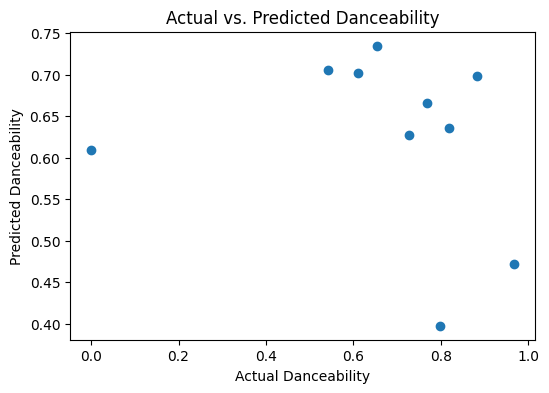

In [106]:
plt.figure(figsize=(6, 4))
plt.scatter(ytest, y_pred1)
plt.xlabel('Actual Danceability')
plt.ylabel('Predicted Danceability')
plt.title('Actual vs. Predicted Danceability')
plt.show()

If the model were highly accurate, the predicted values would closely match the actual values. This means that the data points would follow the line y=x.

In [96]:
from sklearn.metrics import accuracy_score
Xtrain, Xtest, ytrain, ytest=train_test_split(X_songs, y_songs, test_size=0.8, random_state=2)
model2=LinearRegression(fit_intercept=True)
model2.fit(Xtrain, ytrain)

print(f'Slope:{model2.coef_}')
print(f'Intercept:{model2.intercept_}')

Slope:[ 0.22448034  0.20380446 -0.10229856]
Intercept:0.5255359713207344


In [97]:
y_pred2=model2.predict(Xtest)
print(f'R^2 score:{r2_score(ytest, y_pred2):.2f}')
print(f'MSE score:{mean_squared_error(ytest, y_pred2):.2f}')

R^2 score:-0.08
MSE score:0.06


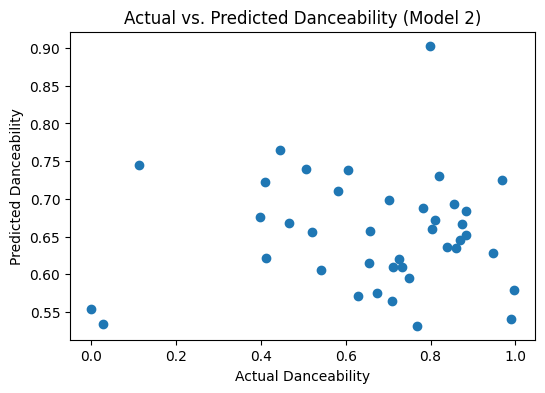

In [98]:
plt.figure(figsize=(6, 4))
plt.scatter(ytest, y_pred2)
plt.xlabel('Actual Danceability')
plt.ylabel('Predicted Danceability')
plt.title('Actual vs. Predicted Danceability (Model 2)')
plt.show()

In [99]:
X_all=normalized_df.drop(columns=['danceability'])
y_all=normalized_df['danceability']

Xtrain, Xtest, ytrain, ytest=train_test_split(X_all, y_all, test_size=0.2, random_state=3)
model3=LinearRegression()
model3.fit(Xtrain, ytrain)

print(f'Slope:{model3.coef_}')
print(f'Intercept:{model3.intercept_}')

Slope:[-3.52761052e-01  1.11362333e-01  3.21845029e-01  2.38341693e-05
  2.54921432e-01 -3.90676055e-01  2.81210377e-01  9.50229874e-02
  3.12087327e-01  4.88107149e-03 -2.40882240e-01  0.00000000e+00]
Intercept:0.5563165883509917


In [100]:
y_pred3=model3.predict(Xtest)
print(f'R^2 score:{r2_score(ytest, y_pred3):.2f}')
print(f'MSE score:{mean_squared_error(ytest, y_pred3):.2f}')

R^2 score:0.23
MSE score:0.02


In [114]:
corr_matrix=normalized_df.corr()
dance_corr=corr_matrix["danceability"].sort_values(ascending=False)
print(dance_corr)

danceability        1.000000
valence             0.391774
energy              0.273068
speechiness         0.227283
loudness            0.178688
key                 0.165208
instrumentalness    0.153419
tempo               0.149066
mode                0.007662
liveness           -0.088595
duration_ms        -0.132798
acousticness       -0.465118
time_signature           NaN
Name: danceability, dtype: float64


- A good model is one that predicts accurately on new data, not just the data it was trained on, and uses variables that are meaningful and relevant to the question being studied. It should also be simple enough to interpret while still capturing the important patterns in the data.
- If I were trying to improve the prediction model, I would test additional variables, and evaluate the model on a separate test set to make sure it generalizes well.

## R^2 and MSE

In [3]:
data = {'Model': ['Model 1', 'Model 2', 'Model 3'],
    'Input Features': ['3 features (liveness, energy, tempo)', 
                       '3 features (Different test split: 0.8)', 
                       'All numeric features'],
    'R-squared': [-0.39, -0.08, 0.23],
    'MSE': [0.03, 0.06, 0.02]
}

results_table = pd.DataFrame(data)

results_table

,Model,Input Features,R-squared,MSE
0,Model 1,"3 features (liveness, energy, tempo)",-0.39,0.03
1,Model 2,3 features (Different test split: 0.8),-0.08,0.06
2,Model 3,All numeric features,0.23,0.02


- Both model 1 and model 2 have negative $R^2$ scores. This shows that using just liveness, energy, and tempo actually create a model that is failing to see the underlying pattern
- Model 3 is the only model with a positive $R^2$ score (0.23). It means that adding all the other available numeric features allows the model to successfully explain 23% of the variation in a song's danceability.
- Model 3 also has the lowest error of 0.02, meaning its predictions are, on average, the closest to the actual true values compared to the other two models